KeyError: 'ADO-KT:unrefined-KG'

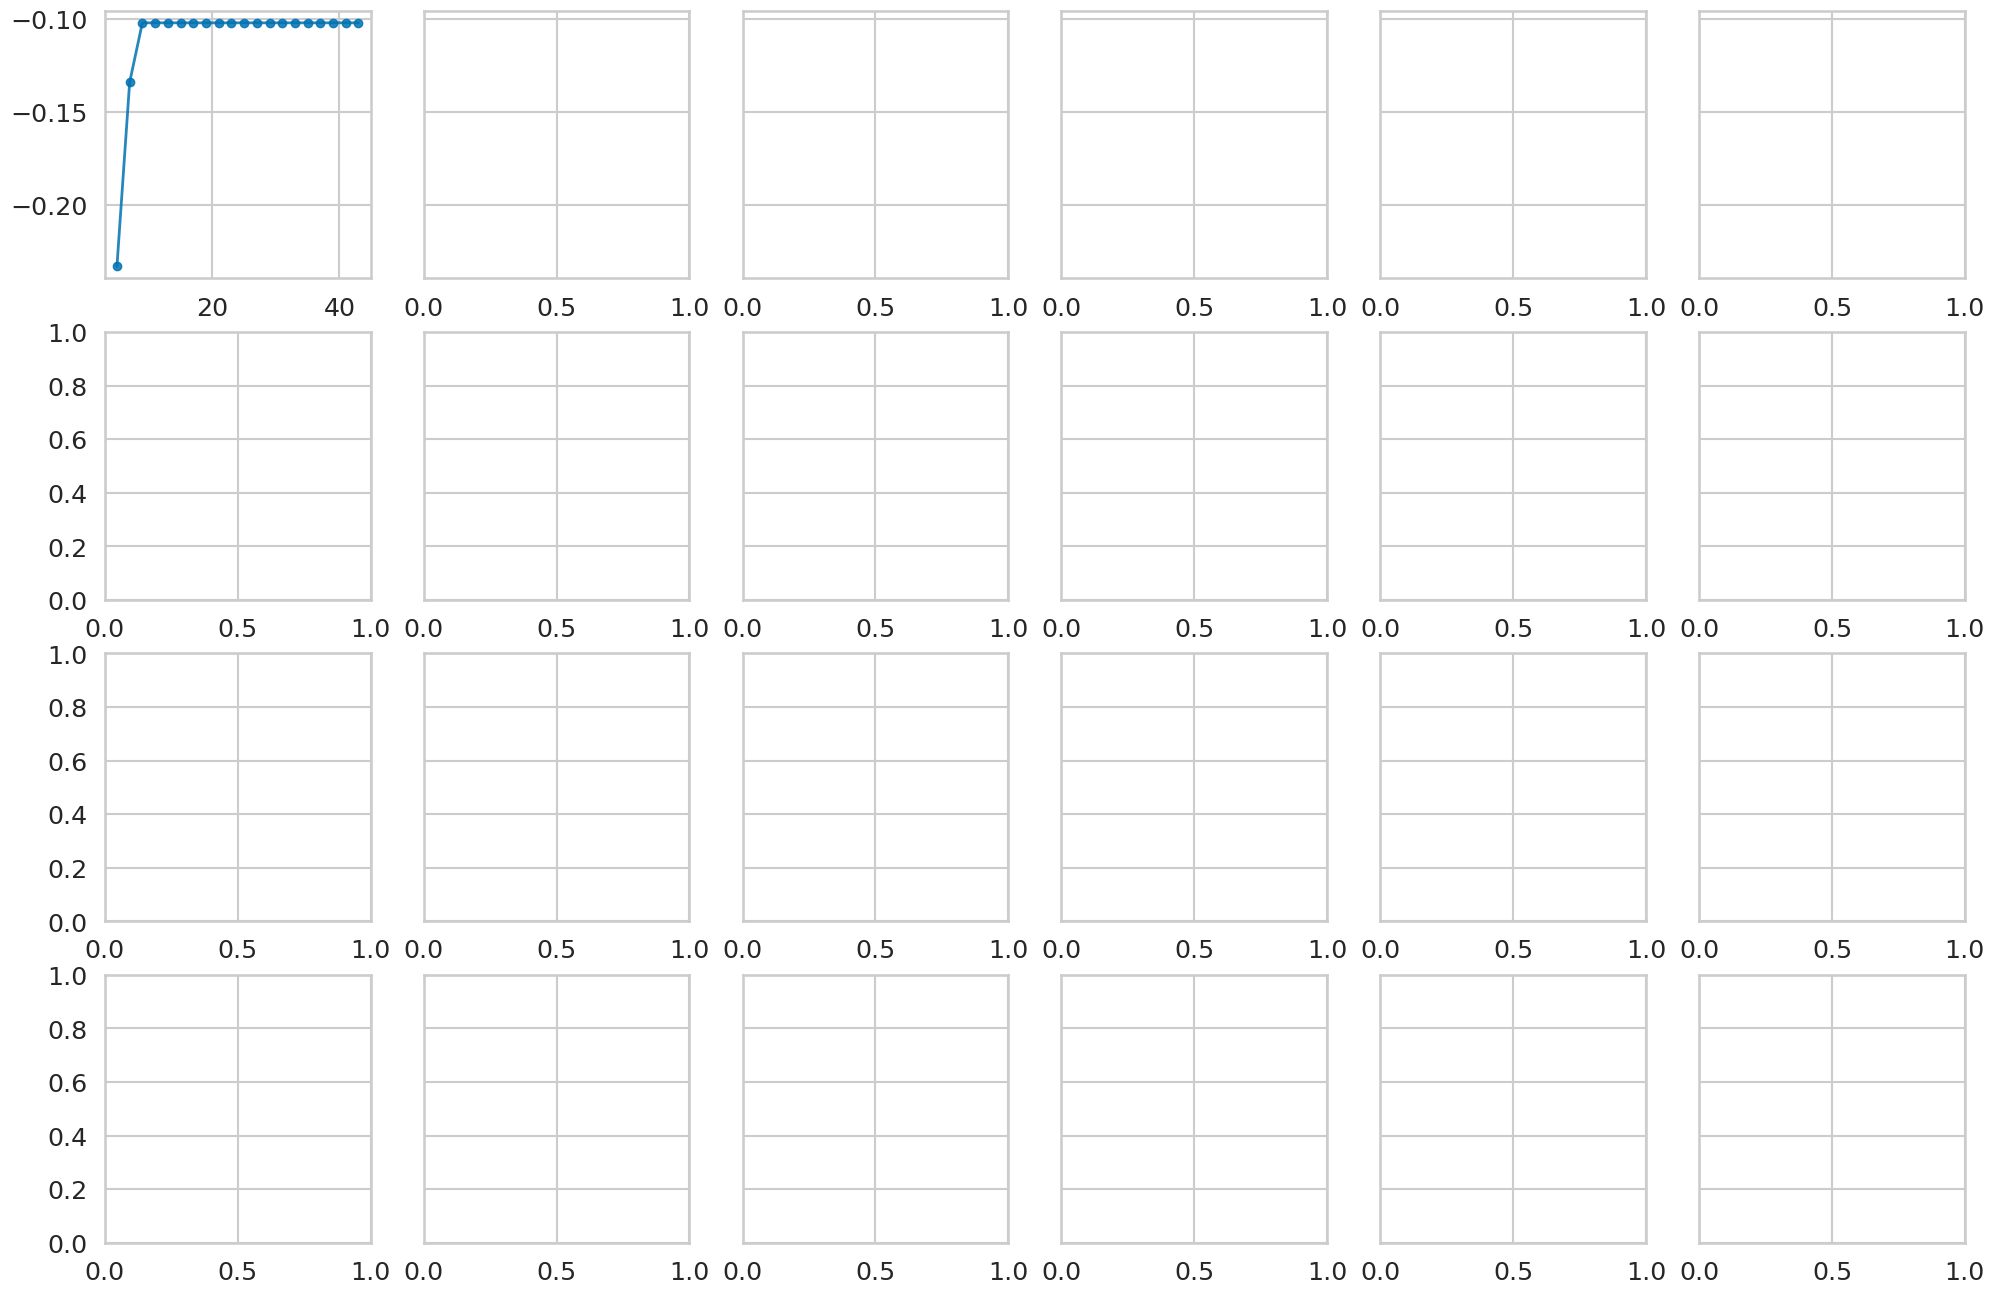

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pypubfigs.palettes import friendly_pal  # pip install pypubfigs

# 1) Theme & Palette
sns.set_theme(
    style="whitegrid",
    palette=friendly_pal("ito_seven"),
    context="talk",
    font_scale=1.1
)
markers = {"ADO‑LLM": "o", "ADO-KT:unrefined-KG": "s", "ADO-KT:refined‑KG": "D"}

# 2) Data
circuits = [
    ("Folded_Cascode_Amplifier", "FC"),
    ("Low_Dropout_Regulator",  "ldo"),
    ("Hysteresis_Comparator",  "comp"),
    ("DCDC_COnverter",  "dcdc")
]
models = [
    "DeepSeek-R1-Distill-Llama-70B",
    "DeepSeek-R1-Distill-Qwen-32B",
    "GPT-4o",
    "llama3-70B-instruct",
    "Qwen2.5-32B-Instruct",
    "Mistral-Small-24B-Instruct-2501"
    #"Qwen2.5-32B-Instruct",
]
methods = {"ADO‑LLM": "0_0", "ADO-KT:unrefined-KG": "1_0", "ADO-KT:refined‑KG": "1_1"}

# 3) Figure setup
fig, axes = plt.subplots(
    nrows=len(circuits),
    ncols=len(models),
    sharex=False,
    sharey="row",
    figsize=(24, 16),
)

# 4) Plotting
for i, (name, short) in enumerate(circuits):
    for j, llm in enumerate(models):
        ax = axes[i, j]
        for m, code in methods.items():
            tag = "GPT-4o" if m == "ADO‑LLM" else llm
            fn = f"results/foms_{code}_{short}_{tag}.txt"
            if not os.path.isfile(fn):
                raise FileNotFoundError(fn)
            data = np.loadtxt(fn)
            x = np.arange(data.shape[0]) * 2 + 5
            y = data
            ax.plot(x, y, label=m,
                    marker=markers[m], linewidth=2.0,
                    markersize=6, alpha=0.85)

        # Styling
        sns.despine(ax=ax, trim=False)
        ax.margins(x=0, y=0)
        ax.set_facecolor("#FAFAFA")
        ax.grid(True, which="major", linestyle="--",
                linewidth=0.5, alpha=0.3)
        ax.minorticks_on()
        ax.tick_params(which="minor", length=4)#, alpha=0.6)
        for spine in ax.spines.values():
            spine.set_edgecolor("#DDDDDD")

        # Labels & Titles
        if i == len(circuits) - 1:
            ax.set_xlabel("No. of data samples", labelpad=8, fontweight = 'bold')
        if i == 0:
            ax.set_title(llm, pad=16, fontsize=15, fontweight = 'bold')

        # Y-axis ticks & label only on last column
        if j == len(models) - 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.tick_params(axis="y", labelleft=False, labelright=True)
            ax.set_ylabel("FOM", labelpad=8, fontweight = 'bold')
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)

        # X ticks styling
        ax.tick_params(axis="x", which="major", labelsize=10)
        ax.tick_params(axis="y", which="major", labelsize=10)

    # Circuit row label
    axes[i, 0].annotate(
        name.replace("_", " "),
        xy=(0, 0.5), xycoords="axes fraction",
        xytext=(-axes[i,0].yaxis.labelpad-20, 0),
        textcoords="offset points",
        ha="right", va="center",
        fontsize=18, rotation=90, fontweight = 'bold'
    )

# 5) Legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center", ncol=len(methods),
           frameon=True, framealpha=0.85, edgecolor="gray",
           title="", title_fontsize=16, fontsize=11)

fig.legend(handles, labels, loc="upper center", ncol=len(methods), frameon=True, framealpha=0.85, edgecolor="gray", title="", title_fontsize=13, fontsize=11, prop={'weight': 'bold'})

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("results/fig_foms.pdf", dpi=300, bbox_inches="tight")


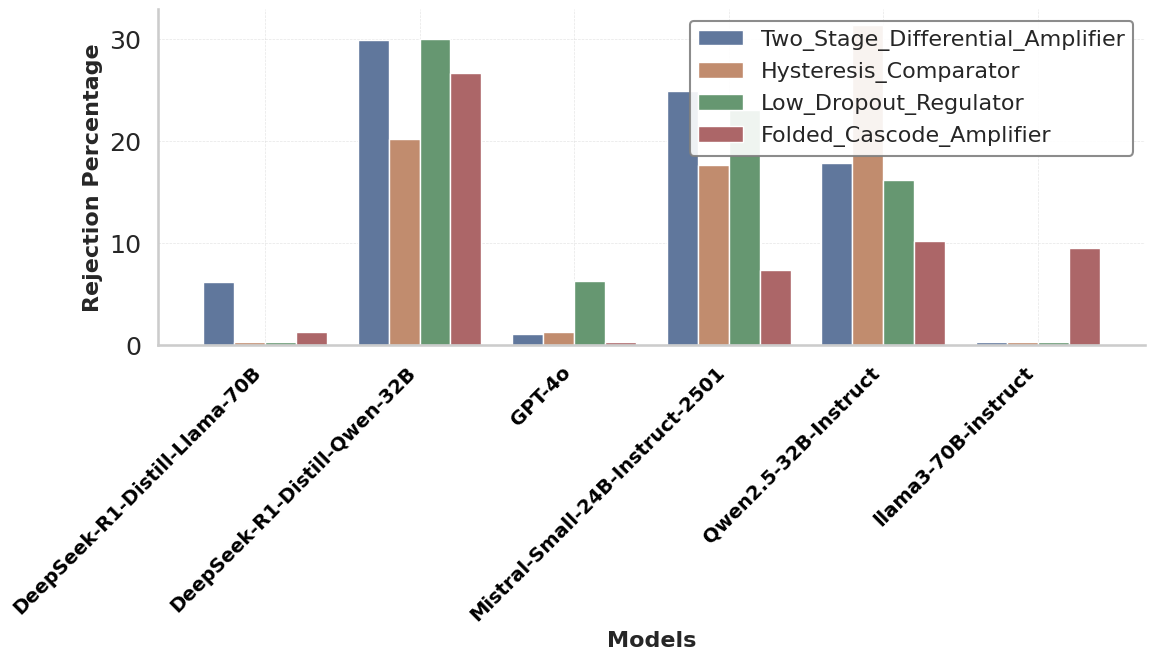

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Set an accessible, elegant theme & palette
sns.set_theme(
    style="whitegrid",            # subtle grid behind data :contentReference[oaicite:6]{index=6}
    palette="muted",         # muted, high‑contrast qualitative palette :contentReference[oaicite:7]{index=7}
    context="talk",               # slightly larger fonts for readability :contentReference[oaicite:8]{index=8}
    font_scale=1.1
)

# 2) Original data parsing code (unchanged)
data = {
    "DeepSeek-R1-Distill-Llama-70B_Two_Stage_Differential_Amplifier": 0.06183574879227053,
    "DeepSeek-R1-Distill-Llama-70B_Hysteresis_Comparator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Low_Dropout_Regulator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Folded_Cascode_Amplifier": 0.012658227848101266,
    "DeepSeek-R1-Distill-Qwen-32B_Two_Stage_Differential_Amplifier": 0.29838709677419356,
    "DeepSeek-R1-Distill-Qwen-32B_Hysteresis_Comparator": 0.20238095238095238,
    "DeepSeek-R1-Distill-Qwen-32B_Low_Dropout_Regulator": 0.29958677685950413,
    "DeepSeek-R1-Distill-Qwen-32B_Folded_Cascode_Amplifier": 0.26609195402298846,
    "GPT-4o_Two_Stage_Differential_Amplifier": 0.0107169811320754715,
    "GPT-4o_Hysteresis_Comparator": 0.012711864406779662,
    "GPT-4o_Low_Dropout_Regulator": 0.06272401433691756,
    "GPT-4o_Folded_Cascode_Amplifier": 0.0,
    "llama3-70B-instruct_Two_Stage_Differential_Amplifier": 0.0,
    "llama3-70B-instruct_Hysteresis_Comparator": 0.0,
    "llama3-70B-instruct_Low_Dropout_Regulator": 0.0,
    "llama3-70B-instruct_Folded_Cascode_Amplifier": 0.09539473684210527,
    "Mistral-Small-24B-Instruct-2501_Two_Stage_Differential_Amplifier": 0.2484709480122324,
    "Mistral-Small-24B-Instruct-2501_Hysteresis_Comparator": 0.17670682730923695,
    "Mistral-Small-24B-Instruct-2501_Low_Dropout_Regulator": 0.23076923076923078,
    "Mistral-Small-24B-Instruct-2501_Folded_Cascode_Amplifier": 0.07391304347826087,
    "Qwen2.5-32B-Instruct_Two_Stage_Differential_Amplifier": 0.17878787878787877,
    "Qwen2.5-32B-Instruct_Hysteresis_Comparator": 0.3131868131868132,
    "Qwen2.5-32B-Instruct_Low_Dropout_Regulator": 0.16196236559139784,
    "Qwen2.5-32B-Instruct_Folded_Cascode_Amplifier": 0.10168195718654433
}
circuits = [
    "Two_Stage_Differential_Amplifier",
    "Hysteresis_Comparator",
    "Low_Dropout_Regulator",
    "Folded_Cascode_Amplifier"
]
models = {}
for key, score in data.items():
    for circuit in circuits:
        if key.endswith(circuit):
            model = key[: -len(circuit) - 1]
            models.setdefault(model, {})[circuit] = max(score, 0.003)
            break
model_names = sorted(models.keys())
scores = {
    circuit: [models[m].get(circuit, 0)*100 for m in model_names]
    for circuit in circuits
}

# 3) Plot setup
N = len(model_names)
ind = np.arange(N)
width = 0.20
fig, ax = plt.subplots(figsize=(12, 7))

# 4) Choose the same color palette for bars
# colors = sns.color_palette("muted", len(circuits))  # :contentReference[oaicite:9]{index=9}
colors = sns.color_palette("deep", len(circuits))
colors = [sns.desaturate(c, 0.6) for c in colors]


# 5) Draw bars with white edges for clarity
bars = []
for i, circuit in enumerate(circuits):
    offset = (i - (len(circuits)-1)/2) * width
    bar = ax.bar(
        ind + offset, scores[circuit], width,
        label=circuit,
        color=colors[i],
        edgecolor="white",         # crisp separation :contentReference[oaicite:10]{index=10}
        linewidth=1
    )
    bars.append(bar)

# 6) Add value labels on top of each bar
# for bar in bars:
#     ax.bar_label(bar, fmt="%.1f", label_type="edge", padding=2)  # :contentReference[oaicite:11]{index=11}

# 7) Styling enhancements
ax.set_xticks(ind)
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=14, color = 'black', fontweight = 'bold')
ax.set_xlabel("Models", fontsize=16, fontweight = 'bold')
ax.set_ylabel("Rejection Percentage", fontsize=16,fontweight = 'bold')

# Bring grid behind bars, soften its appearance
ax.set_axisbelow(True)
ax.grid(
    True, which="major",
    linestyle="--", linewidth=0.5, alpha=0.5  # lighter dash :contentReference[oaicite:12]{index=12}
)

# Enable minor ticks for subtle reference lines
ax.minorticks_on()
ax.tick_params(which="minor", length=4)#, alpha=0.6)  # :contentReference[oaicite:13]{index=13}

# Remove top/right spines for a cleaner look
sns.despine(ax=ax, top=True, right=True)  # :contentReference[oaicite:14]{index=14}

# Legend styling
leg = ax.legend(title="", fontsize=16, title_fontsize=13, framealpha=0.9)
leg.get_frame().set_edgecolor("gray")

plt.tight_layout()
plt.savefig("results/fig_rejection_scores.pdf", dpi=300, bbox_inches='tight')  # Save the figure


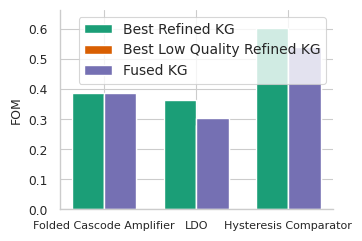

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1) Your data
best_KG_refined = {
    "Folded_Cascode_Amplifier": 0.389,
    "LDO":    0.365,
    "Hysteresis_Comparator":    0.604
}

best_low_quality_KG_refined = {
    "Folded_Cascode_Amplifier": 0.382,
    "LDO":    0.280,
    "Hysteresis_Comparator":    0.529
}

KG_fused = {
    "Folded_Cascode_Amplifier": 0.386,
    "LDO":    0.305,
    "Hysteresis_Comparator":    0.540
}

circuits = list(best_KG_refined.keys())
y1 = [best_KG_refined[c] for c in circuits]
y2 = [KG_fused[c]        for c in circuits]
y3 = [best_low_quality_KG_refined[c]        for c in circuits]

# 2. Plot setup
sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)
palette = sns.color_palette("Dark2", 3)

x = np.arange(len(circuits))
width = 0.35
fig, ax = plt.subplots(figsize=(4.5, 2.5))  # single‑column width

# 3. Draw bars
bars1 = ax.bar(x - width/2, y1, width,
               label="Best Refined KG",
               color=palette[0],
               edgecolor="white", linewidth=1)
bars3 = ax.bar(x + width/2, y3, width,
               label="Best Low Quality Refined KG",
               color=palette[1],
               edgecolor="white", linewidth=1)
bars2 = ax.bar(x + width/2, y2, width,
               label="Fused KG",
               color=palette[2],
               edgecolor="white", linewidth=1)


# 4. Labels & styling
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", " ") for c in circuits],
                   rotation=0, fontsize=8)
ax.set_ylabel("FOM", fontsize=9)
ax.set_ylim(0, max(y1 + y2) * 1.1)

# 5. Legend placed outside
# ax.legend(
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     frameon=True,
#     fontsize=10
# )
ax.legend(loc="upper right", frameon=True, fontsize=10)

sns.despine(ax=ax, top=True, right=True)

# 6. Tight layout with room for legend
plt.tight_layout()
fig.subplots_adjust(right=0.75)  # make space on the right for the legend

plt.show()


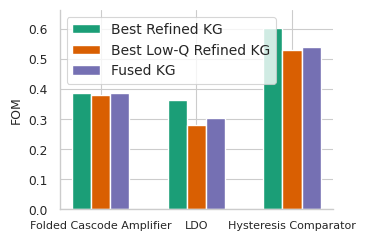

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1) Your data
best_KG_refined = {
    "Folded_Cascode_Amplifier": 0.389,
    "LDO":    0.365,
    "Hysteresis_Comparator":    0.604
}

best_low_quality_KG_refined = {
    "Folded_Cascode_Amplifier": 0.382,
    "LDO":    0.280,
    "Hysteresis_Comparator":    0.529
}

KG_fused = {
    "Folded_Cascode_Amplifier": 0.386,
    "LDO":    0.305,
    "Hysteresis_Comparator":    0.540
}

circuits = list(best_KG_refined.keys())
y1 = [best_KG_refined[c] for c in circuits]
y2 = [best_low_quality_KG_refined[c] for c in circuits]
y3 = [KG_fused[c]        for c in circuits]

# 2. Plot setup
sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)
palette = sns.color_palette("Dark2", 3)

x = np.arange(len(circuits))
width = 0.2                # narrower bars
fig, ax = plt.subplots(figsize=(4.5, 2.5))

# 3. Draw bars at three offsets
bars1 = ax.bar(x - width, y1, width,
               label="Best Refined KG",
               color=palette[0],
               edgecolor="white", linewidth=1)
bars2 = ax.bar(x,      y2, width,
               label="Best Low‑Q Refined KG",
               color=palette[1],
               edgecolor="white", linewidth=1)
bars3 = ax.bar(x + width, y3, width,
               label="Fused KG",
               color=palette[2],
               edgecolor="white", linewidth=1)

# 4. Labels & styling
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", " ") for c in circuits],
                   rotation=0, fontsize=8)
ax.set_ylabel("FOM", fontsize=9)
ax.set_ylim(0, max(max(y1), max(y2), max(y3)) * 1.1)

# 5. Legend outside
# ax.legend(
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     frameon=False,
#     fontsize=10
# )

ax.legend(loc="upper left", frameon=True, fontsize=10)
sns.despine(ax=ax, top=True, right=True)

# 6. Tight layout + room for legend
plt.tight_layout()
fig.subplots_adjust(right=0.75)

plt.savefig("results/fig_fused_KG.pdf", dpi=300, bbox_inches='tight')  # Save the figure
